# Lecture 6 — Column Space and Nullspace
Instructor: Gilbert Strang

In this lecture, we connect vector spaces to solving linear systems.

Previously, we studied subspaces and column spaces geometrically.
Now we ask a central question:

When does Ax = b have a solution?

The answer will depend on two fundamental spaces:

1) The column space of A
2) The nullspace of A

Column space lives in R^m (the space of b).
Nullspace lives in R^n (the space of x).

Understanding these two spaces explains:

- When a system is solvable
- Why some systems have infinitely many solutions
- Why some have none

This lecture is about structure, not just computation.

## 1. Subspaces Inside R^3

A subspace must:

- Contain the zero vector
- Be closed under addition
- Be closed under scalar multiplication

In R^3, common subspaces are:

- A plane through the origin
- A line through the origin
- The zero vector alone
- The entire space R^3

We now visualize a plane and a line inside R^3.

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from sympy import Matrix


In [11]:
x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)

X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

print("X: \n", X.shape, "\n")
print("Y: \n", Y.shape, "\n")
print("Z: \n", Z.shape, "\n")

X: 
 (50, 50) 

Y: 
 (50, 50) 

Z: 
 (50, 50) 



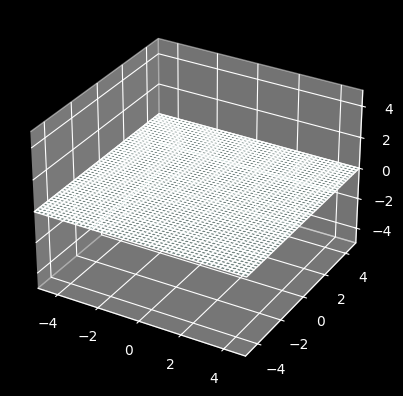

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, alpha=0.3)
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_zlim(-5, 5)
plt.show()

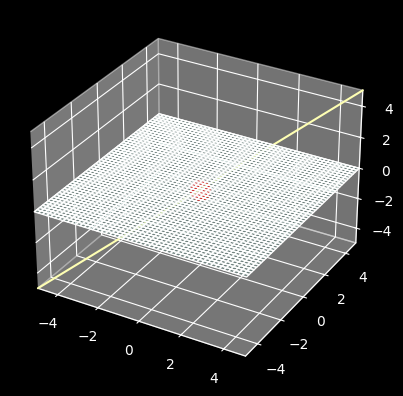

In [26]:
t = np.linspace(-5, 5, 100)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, alpha=0.3)
ax.plot(t, t, t)
ax.scatter(0, 0, 0, s=200, color='red', alpha=1)
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_zlim(-5, 5)
plt.show()

### Union vs Intersection of Subspaces

Let:

P = plane z = 0
L = line t(1,1,1)

Intersection:
Only the zero vector lies in both.
So P ∩ L is a subspace.

Union:
Take one vector from P and one from L.
Their sum is generally in neither.
So P ∪ L is not closed under addition.

Union of subspaces is usually not a subspace.
Intersection of subspaces is always a subspace.

In [37]:

v_plane = np.array([1, 0, 0])
v_line = np.array([1, 1, 1])
v_sum = v_plane + v_line

print("v_plane:")
display(Matrix(v_plane))

print("v_line:")
display(Matrix(v_line))

print("v_sum:")
display(Matrix(v_sum))

v_plane:


Matrix([
[1],
[0],
[0]])

v_line:


Matrix([
[1],
[1],
[1]])

v_sum:


Matrix([
[2],
[1],
[1]])

### Structural Result

We observed:

- A plane through the origin is a subspace.
- A line through the origin is a subspace.
- The intersection of subspaces is always a subspace.
- The union of subspaces is generally not a subspace.

Subspaces are strict.
Closure under addition is non-negotiable.

## 2. Column Space and Solving Ax = b

Consider the matrix:

A =
[[1  1  2],
 [2  1  3],
 [3  1  4],
 [4  1  5]]

This matrix has:

- 4 rows
- 3 columns

So A maps vectors x in R^3
to vectors b in R^4.

The column space of A, denoted C(A), is:

All linear combinations of the columns of A.

The central question:

Does Ax = b have a solution for every b in R^4?

We now investigate.

In [38]:
A = np.array([
    [1, 1, 2],
    [2, 1, 3],
    [3, 1, 4],
    [4, 1, 5]
])
print("A: ")
display(Matrix(A))

A: 


Matrix([
[1, 1, 2],
[2, 1, 3],
[3, 1, 4],
[4, 1, 5]])

In [47]:
A.shape

(4, 3)

In [39]:
A_c1 = A[:, 0]
A_c2 = A[:, 1]
A_c3 = A[:, 2]

print("A_c1: ")
display(Matrix(A_c1))
print("A_c2: ")
display(Matrix(A_c2))
print("A_c3: ")
display(Matrix(A_c3))

A_c1: 


Matrix([
[1],
[2],
[3],
[4]])

A_c2: 


Matrix([
[1],
[1],
[1],
[1]])

A_c3: 


Matrix([
[2],
[3],
[4],
[5]])

In [48]:
c_sum = A_c1 + A_c2
print("c_sum: ")
Matrix(c_sum)

c_sum: 


Matrix([
[2],
[3],
[4],
[5]])

### Column Dependence

We observed:

c3 = c1 + c2

So the third column does not add a new direction.

The columns of A span a 2-dimensional subspace of R^4.

Therefore:

C(A) is a plane inside R^4.

Since R^4 is 4-dimensional,
a 2-dimensional subspace cannot fill it.

So Ax = b cannot have a solution for every b in R^4.

### A Plane Inside R^4

The column space of A is 2-dimensional, but it lives inside R^4.

We cannot visualize R^4 directly,
just as a 3D creature cannot see a 4D object.

However, structure does not depend on visualization.

A 2-dimensional subspace inside R^4 behaves like a plane:

- It has two independent directions.
- Every vector in it is a linear combination of two basis vectors.
- Moving in those two directions keeps us inside the subspace.

Even though we cannot draw it,
algebra tells us its geometry.

So C(A) is a plane — not in R^3,
but inside the larger space R^4.

In [63]:
np.linalg.matrix_rank(A)

np.int64(2)

### Confirming the Rank

The rank of A is 2.

Rank equals the dimension of the column space.

This confirms that C(A) is a 2-dimensional subspace of R^4.

### Generating b from Known x

Instead of asking immediately which b work,
we generate b by choosing x and computing:

b = A x

Every such b must lie in the column space.

If we understand what these b look like,
we understand C(A).

In [49]:
x1 = np.array([0, 0, 0])
x2 = np.array([1, 0, 0])
x3 = np.array([0, 1, 0])
x4 = np.array([0, 0, 1])

A_x1 = A @ x1
A_x2 = A @ x2
A_x3 = A @ x3
A_x4 = A @ x4

print("A @ x1: ")
display(Matrix(A_x1))
print("A @ x2: ")
display(Matrix(A_x2))
print("A @ x3: ")
display(Matrix(A_x3))
print("A @ x4: ")
display(Matrix(A_x4))

A @ x1: 


Matrix([
[0],
[0],
[0],
[0]])

A @ x2: 


Matrix([
[1],
[2],
[3],
[4]])

A @ x3: 


Matrix([
[1],
[1],
[1],
[1]])

A @ x4: 


Matrix([
[2],
[3],
[4],
[5]])

### Structure of the Column Space

We observed:

Ax = x1 c1 + x2 c2 + x3 c3

Since c3 = c1 + c2,

Ax = (x1 + x3) c1 + (x2 + x3) c2

So every vector b in the column space is a linear combination of c1 and c2.

The column space of A is therefore a 2-dimensional subspace of R^4.

Ax = b has a solution exactly when b lies in this plane.

## 3. The Nullspace of A

The nullspace of A is:

N(A) = { x in R^3 | A x = 0 }

It contains all vectors x that produce the zero vector in R^4.

This space lives in R^3,
because x has three components.

We now solve:

A x = 0

In [50]:
v = np.array([1, 1, -1])
A_v = A @ v

print("A @ v: ")
Matrix(A_v)

A @ v: 


Matrix([
[0],
[0],
[0],
[0]])

### Structure of the Nullspace

We observed a dependence:

c1 + c2 − c3 = 0

This gives a nullspace vector:

v = (1, 1, −1)

Since A v = 0,
any scalar multiple also satisfies A (c v) = 0.

Therefore:

N(A) = { t (1, 1, −1) }

The nullspace is a 1-dimensional subspace of R^3.
It is a line through the origin.

### Visualizing the Nullspace

The nullspace consists of all vectors:

x = t (1, 1, −1)

This is a line through the origin in R^3.

We now visualize this line to see the structure of N(A).

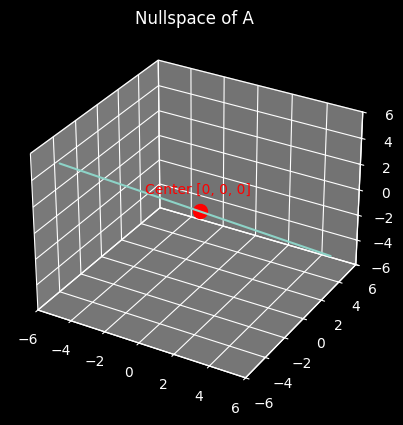

In [62]:
t = np.linspace(-5, 5, 100)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(t, t, -t)
ax.scatter(0, 0, 0, s=100, color='red', alpha=1)
ax.text(-2,-2,2, "Center [0, 0, 0]", color='red')
ax.set_title("Nullspace of A")
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_zlim(-6, 6)
plt.show()

### Why the Nullspace Is Always a Subspace

If Av = 0 and Aw = 0,

Then:

A(v + w) = Av + Aw = 0

If Av = 0 and c is any scalar,

Then:

A(cv) = cAv = 0

So the nullspace is closed under addition and scalar multiplication.

Therefore, N(A) is always a subspace.

In [61]:
v1 = np.array([1, 1, -1])
v2 = 2 * np.array([1, 1, -1])
A_v1_plus_v2 = A @ (v1 + v2)
A_3_mal_v1 = A @ (3 * v1)

print("A_v2_plus_v2: ")
display(Matrix(A_v1_plus_v2))
print("A_3_mal_v1: ")
display(Matrix(A_3_mal_v1))

A_v2_plus_v2: 


Matrix([
[0],
[0],
[0],
[0]])

A_3_mal_v1: 


Matrix([
[0],
[0],
[0],
[0]])

## Conceptual Conclusion

For the matrix A:

- The column space C(A) is a 2-dimensional subspace of R^4.
- Ax = b has a solution exactly when b lies in C(A).
- The nullspace N(A) is a 1-dimensional subspace of R^3.
- Nullspace consists of all directions in x that A sends to zero.

Column space controls solvability.
Nullspace controls freedom in solutions.

Together, they explain the structure of Ax = b.